# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание. Нейронные сети

### Общая информация

Дата выдачи: 24.03.2026

Мягкий дедлайн: 14.04.2026 23:59

Жесткий дедлайн: 19.04.2026 23:59

### О задании

В этой работе две независимые части:

- Часть 1. Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца - 4 балла.

- Часть 2. CNN-классификация звуков на датасете UrbanSound8K - 6 баллов.

### Оценивание

Максимально допустимая оценка за работу - 10 баллов. 4 балла за SPINN и 6 баллов за CNN.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке. Оценка также может быть снижена за плохо читаемый код и плохо оформленные диаграммы/таблицы. Изменять проверочные ячейки и пороги `assert` запрещено.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Про вычислительные ресурсы

Задание рассчитано на выполнение в бесплатном Google Colab или Kaggle Notebook, если реализация сделана разумно.

- Используйте GPU экономно: черновую отладку, проверку кода и подготовку пайплайна лучше сначала выполнять на CPU, а GPU подключать уже для обучения и финальных экспериментов. Это поможет избежать лишних проблем с памятью и не тратить ресурсы впустую.
- Для SPINN обучение должно занимать умеренное время; если одна конфигурация обучается слишком долго, стоит проверить размер модели, число коллокационных точек и эффективность реализации.
- Для UrbanSound8K рекомендуется предвычислять спектрограммы и сохранять их на диск. Без этого эксперименты часто упираются в CPU-препроцессинг, а не в обучение модели.
- Для подбора гиперпараметров разумно сначала работать на одном фиксированном dev-split, а полный 10-fold cross-validation запускать только для финальной модели.
- При обучении свёрточных сетей может помочь `torch.backends.cudnn.benchmark = True`.

### Формат сдачи

Задания сдаются через систему Anytask. Необходимо прислать ноутбук с выполненным заданием; к ноутбуку прикрепите два файла с весами лучших моделей для каждой из двух задач: `best_spinn_model.pth` и `best_cnn_model.pth`. Сам ноутбук называйте в формате `homework-practice-04-dl-Username.ipynb`, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку, исходя из набора выполненных задач и достигнутого качества, и укажите её ниже.

Оценка: 9.5






In [ ]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import librosa
import librosa.display
from IPython.display import Audio

In [ ]:
random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Часть 1. SPINN для 3D-уравнения Гельмгольца (4 балла)


### Разбалловка

Для удобства разбалловка задания представлена в таблице ниже. В первой части основное внимание уделяется корректной реализации SPINN-архитектуры, организации обучения и анализу результатов.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 1.1 Реализация separable-архитектуры | **2,0** | Реализация класса `BaseSPINN`: три body-сети, корректная separable-сборка решения на решётке и на произвольных точках, согласованность с `BaseModel` |
| 1.2 Обучение и качество | **1,5** | Модель сходится, обучение организовано корректно, результат воспроизводим, достигнуто разумное качество на тестовой сетке |
| 1.3 Анализ экспериментов | **0,5** | Краткий разбор выбранной конфигурации и наблюдений по качеству и скорости


### Что такое PINN

**Physics-Informed Neural Networks (PINNs)** - это нейросетевые модели, которые используют для обучения не только данные, но и структуру самой физической задачи.

Идея состоит в том, что модель должна не просто приближать неизвестную функцию, а строить решение, которое согласовано с заданным дифференциальным уравнением и граничными условиями.

В отличие от стандартной постановки supervised learning, где у нас есть множество пар "вход-ответ", в PINN функция потерь обычно включает две части:

- PDE loss - это невязка дифференциального уравнения внутри области;
- BC loss - это ошибка на границе области, где известны граничные условия.

Благодаря этому PINN можно применять даже в ситуациях, когда наблюдений мало, но сама структура задачи хорошо известна.

Физика - ммм, уже испугались?)

> На деле, глубоко разбираться в физике здесь не требуется. Вся постановка задачи первой части - уравнение, точное решение, функция источника и граничные условия - уже реализована в `BaseModel`.

Для выполнения задания достаточно понимать следующее:

- есть неизвестная функция $u(x, y, z)$, которую нужно приблизить нейросетью;
- внутри области решение должно удовлетворять дифференциальному уравнению (PDE loss);
- на границе куба решение должно обращаться в ноль (BC loss);
- точное решение нам известно, поэтому мы можем измерять ошибку модели после обучения.

**Ваша задача - реализовать архитектуру SPINN**, а не выводить физические формулы с нуля.

> *SPINN - чего?* 😧

### Что такое SPINN

**SPINN (Separable Physics-Informed Neural Network)** - это архитектурная модификация PINN для многомерных задач.  

[Статья: *Separable Physics-Informed Neural Networks*, NeurIPS 2023](https://arxiv.org/abs/2306.15969)

В обычном PINN одна большая сеть получает на вход сразу точку $(x, y, z)$ и предсказывает значение функции $u(x, y, z)$.

В SPINN идея другая: вместо одной общей сети используются несколько небольших сетей - по одной на каждую координату.  

Для нашей 3D-задачи это означает:

- первая сеть обрабатывает только $x$;
- вторая сеть обрабатывает только $y$;
- третья сеть обрабатывает только $z$.

Каждая из этих сетей возвращает вектор длины `rank`, а итоговое решение собирается через CP-подобное объединение:

$$
u[i, j, k] = \sum_{r=1}^{\text{rank}} f_x[i, r] \cdot f_y[j, r] \cdot f_z[k, r].
$$

Интуитивно это похоже на CP-декомпозицию ([Canonical Polyadic decomposition](https://en.wikipedia.org/wiki/Tensor_rank_decomposition#:~:text=clarification%20needed%5D-,Canonical%20polyadic%20decomposition%20(CPD),-is%20a%20variant)), где трёхмерный тензор представляется как сумма тензоров ранга 1:

$$
\hat{u} = \sum_{r=1}^{R} \mathbf{f}_r^{(x)} \otimes \mathbf{f}_r^{(y)} \otimes \mathbf{f}_r^{(z)}.
$$

Главная идея здесь в том, что на tensor-product grid можно отдельно обработать оси, а затем собрать итоговый тензор решения. Именно поэтому SPINN особенно удобен для многомерных PDE-задач, где pointwise-подход быстро становится вычислительно дорогим.

> В этой домашней работе мы используем **учебную реализацию ключевой идеи SPINN**: separable body-сети + CP-merge. Вам не нужно воспроизводить все технические детали статьи; важно корректно реализовать архитектуру и получить рабочее решение.
>
> Но если вам захочется погрузиться в задачу максимально - препятствовать не будем, скорее замолвим за вас словечко в [LAMBDA](https://cs.hse.ru/iai/lambda/).

### Уравнение Гельмгольца

В задаче рассматривается 3D-уравнение Гельмгольца:

$$
\nabla^2 u + k^2 u = q(x,y,z), \quad (x,y,z) \in [-1,1]^3, \quad u\big|_{\text{граница}} = 0.
$$

Здесь:

- $u(x,y,z)$ - неизвестная функция;
- $k$ - волновое число;
- $q(x,y,z)$ - правая часть (источник);
- на границе области заданы нулевые граничные условия Дирихле.

Для тестирования используется точное решение:

$$
u(x,y,z) = \sin(\pi x)\sin(\pi y)\sin(\pi z).
$$

На всех шести гранях куба $\Omega = [-1,1]^3$ задаются нулевые граничные условия:

$$
u(x,y,z) = 0, \quad (x,y,z) \in \partial \Omega.
$$

### Описание задания

В этой части вам нужно:

1. реализовать три независимые body-сети —- по одной для каждой координаты;
2. получить из них separable-представление решения;
3. корректно объединить выходы через CP-merge;
4. реализовать вычисление модели на решётке и на произвольных точках;
5. обучить модель, оценить качество решения на тестовой сетке и проанализировать результаты.

Несколько вспомогательных функций для точного решения, оценки ошибки и визуализации:

In [ ]:
def helmholtz3d_exact_u(a1, a2, a3, x, y, z):
    return (
        torch.sin(a1 * torch.pi * x)
        * torch.sin(a2 * torch.pi * y)
        * torch.sin(a3 * torch.pi * z)
    )


def relative_l2(u_pred, u_true):
    """Относительная L2-ошибка: ||u_pred - u_true|| / ||u_true||"""
    return torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)

А тут вспомогательные функции для визуализации и оценки: код уже готов и нужен вам как инфраструктура для экспериментов. Он помогает визуализировать решение, отслеживать динамику loss'ов, считать ошибку на тестовой сетке и пересэмплировать коллокационные точки.

In [ ]:
def plot_helmholtz3d(x, y, z, u):
    x = x.detach().cpu().numpy().flatten()
    y = y.detach().cpu().numpy().flatten()
    z = z.detach().cpu().numpy().flatten()
    u = u.detach().cpu().numpy().flatten()

    u_norm = (u - u.min()) / (u.max() - u.min() + 1e-10)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        x, y, z,
        c=u_norm,
        s=1,
        cmap="seismic",
        vmin=0,
        vmax=1,
        alpha=0.75,
        edgecolors="none",
    )

    ax.set_title("U(x, y, z)", fontsize=18)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    cbar = plt.colorbar(scatter, shrink=0.8, aspect=15)
    cbar.set_label("u(x,y,z)")

    plt.tight_layout()
    plt.show()


def plot_losses(
    loss_history,
    residual_history,
    boundary_history,
    error_history,
    log_iter,
    title_prefix="",
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.semilogy(loss_history, label="Total Loss", linewidth=2)
    ax1.semilogy(residual_history, label="PDE Loss", alpha=0.7)
    ax1.semilogy(boundary_history, label="BC Loss", alpha=0.7)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss (log scale)")
    ax1.set_title(f"{title_prefix}Training Losses")

    iterations = np.arange(0, len(error_history) * log_iter, log_iter)
    ax2.semilogy(iterations, error_history, "r-", linewidth=2, label="Relative L2 Error")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Error (log scale)")
    ax2.set_title(f"{title_prefix}Relative L2 Error")

    plt.tight_layout()
    plt.show()


def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    """
    Вычисление ошибки модели на фиксированной сетке.
    """

    was_training = model.training
    model.eval()

    with torch.no_grad():
        coords = torch.stack(
            [x_grid.flatten(), y_grid.flatten(), z_grid.flatten()],
            dim=1,
        )
        u_pred = model(coords)
        error = relative_l2(u_pred, u_true.flatten())

    if was_training:
        model.train()

    return error, u_pred.reshape(x_grid.shape)


def resample_collocation_points(model, NC, domain_size=1.0):
    """
    Ресэмплирование коллокационных точек на кубической решётке.
    """

    N_per_axis = int(round(NC ** (1 / 3)))

    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)

    xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")

    xc = xx.flatten().requires_grad_(True)
    yc = yy.flatten().requires_grad_(True)
    zc = zz.flatten().requires_grad_(True)

    return xc, yc, zc

Глянем на визуальзацию точного решения на тестовой сетке.

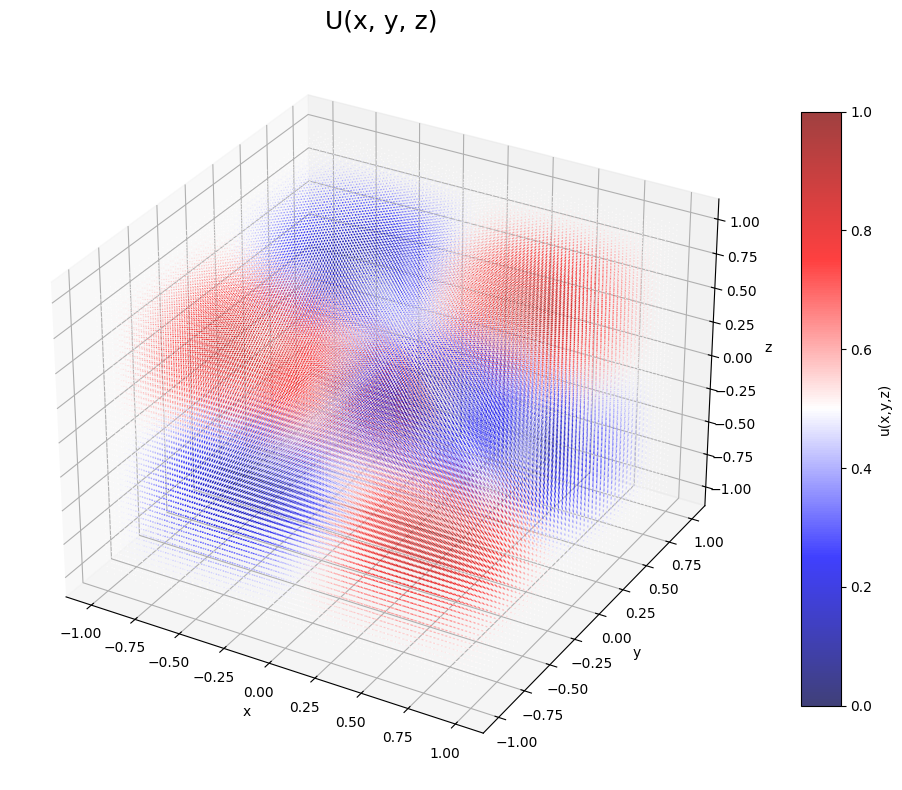

In [ ]:
N_test = 50

x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing="ij")
u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

### Задание 1.1. Реализуйте SPINN-архитектуру (2 балла)

В этом пункте нужно реализовать дочерний класс от `BaseModel`, который задаёт Separable Physics-Informed Neural Network для трёхмерного уравнения Гельмгольца.

Идея остаётся той же, что и в [статье](https://arxiv.org/pdf/2306.15969): вместо одной сети, работающей сразу с тройкой координат, используется три независимые body-сети - для $x$, $y$ и $z$. Их выходы затем объединяются в separable-представление решения

$$
u(x,y,z)=\sum_{j=1}^r f_j^{(1)}(x)\,f_j^{(2)}(y)\,f_j^{(3)}(z).
$$

Базовый класс уже содержит всю постановку задачи: точное решение, правую часть уравнения, граничные условия, вычисление `PDE loss` и `BC loss`. Менять его не нужно. Ваша часть работы - архитектура.

Что именно требуется:
- собрать класс `BaseSPINN`;
- реализовать три независимые body-сети;
- определить, как из их выходов получается решение на полной решётке;
- отдельно продумать, как считать модель на произвольном наборе точек, когда координаты уже не образуют декартово произведение.

Здесь важно не просто получить рабочий код, а аккуратно разобраться в размерностях. От того, какие формы имеют выходы body-сетей, зависит и корректность `forward`, и вычисление PDE loss.

После реализации сделайте короткую sanity check-проверку:
- создайте маленькую модель;
- проверьте формы выходов body-сетей;
- убедитесь, что на решётке получается тензор формы `(Nx, Ny, Nz)`;
- отдельно проверьте вычисление на наборе произвольных точек.

In [ ]:
# здесь ничего не меняем - изучаем, переиспользуем

class BaseModel(nn.Module):
    """
    Базовый класс для 3D-уравнения Гельмгольца на кубе [-1, 1]^3.

    Здесь уже реализованы:
    - точное решение и правая часть PDE;
    - граничные точки на 6 гранях куба;
    - вычисление PDE loss и BC loss.

    В этом задании предполагается, что студент реализует только
    архитектурную часть в наследнике BaseSPINN.
    """

    def __init__(
        self,
        x_min: float = -1.0,
        x_max: float = 1.0,
        y_min: float = -1.0,
        y_max: float = 1.0,
        z_min: float = -1.0,
        z_max: float = 1.0,
        k: float = 1.0,
        a1: int = 1,
        a2: int = 1,
        a3: int = 1,
        N_bc: int = 32,
        device: torch.device = None,
    ):
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N_bc = N_bc
        self.k = k
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")
        self._init_boundary_points()

    def _init_boundary_points(self):
        N = self.N_bc
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        faces = []

        for x_val in [self.x_min, self.x_max]:
            yy, zz = torch.meshgrid(lin_y, lin_z, indexing="ij")
            xx = torch.full_like(yy, x_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for y_val in [self.y_min, self.y_max]:
            xx, zz = torch.meshgrid(lin_x, lin_z, indexing="ij")
            yy = torch.full_like(xx, y_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for z_val in [self.z_min, self.z_max]:
            xx, yy = torch.meshgrid(lin_x, lin_y, indexing="ij")
            zz = torch.full_like(xx, z_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for i, coords in enumerate(faces, 1):
            self.register_buffer(f"coords_bc{i}", coords.to(self.device))
            self.register_buffer(
                f"zeros_bc{i}",
                torch.zeros(coords.shape[0], 1, device=self.device)
            )

    def reference_solution(self, x, y, z):
        """Точное решение. Используется только для оценки ошибки."""
        return (
            torch.sin(self.a1 * np.pi * x)
            * torch.sin(self.a2 * np.pi * y)
            * torch.sin(self.a3 * np.pi * z)
        )

    def function_of_source(self, x, y, z):
        """Правая часть PDE, полученная подстановкой точного решения."""
        u = self.reference_solution(x, y, z)
        lap_coef = -(self.a1 * np.pi) ** 2 - (self.a2 * np.pi) ** 2 - (self.a3 * np.pi) ** 2
        return (lap_coef + self.k**2) * u

    def get_body_outputs(self, x, y, z):
        """
        Должен быть реализован в наследнике.

        Ожидаемые формы:
        - x: (Nx,), y: (Ny,), z: (Nz,)
        - f_x: (Nx, rank), f_y: (Ny, rank), f_z: (Nz, rank)
        """
        raise NotImplementedError

    def forward(self, x, y, z):
        """
        Значения решения на полной декартовой решётке.
        """
        raise NotImplementedError

    def forward_pointwise(self, coords):
        """
        Значения решения на произвольном наборе точек coords формы (B, 3).
        """
        raise NotImplementedError

    @staticmethod
    def _body_second_deriv(f, inp):
        """
        Вторая производная по одной координате для каждого канала ранга.
        Предполагается, что f.shape == (N, rank), inp.shape == (N,).
        """
        _, rank = f.shape
        d2 = torch.zeros_like(f)

        for r in range(rank):
            d1 = torch.autograd.grad(f[:, r].sum(), inp, create_graph=True)[0]
            d2[:, r] = torch.autograd.grad(d1.sum(), inp, create_graph=True)[0]

        return d2

    def calculate_pde_loss(self, x_col, y_col, z_col):
        """
        PDE loss на коллокационной решётке.
        """
        x = x_col.clone().detach().requires_grad_(True)
        y = y_col.clone().detach().requires_grad_(True)
        z = z_col.clone().detach().requires_grad_(True)

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        f_x_d2 = self._body_second_deriv(f_x, x)
        f_y_d2 = self._body_second_deriv(f_y, y)
        f_z_d2 = self._body_second_deriv(f_z, z)

        u = self.forward(x, y, z)

        lap = (
            torch.einsum("ir,jr,kr->ijk", f_x_d2, f_y, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y_d2, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y, f_z_d2)
        )

        xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")
        q = self.function_of_source(xx, yy, zz)

        residual = lap + self.k**2 * u - q
        return self.mse(residual, torch.zeros_like(residual))

    def calculate_bc_loss(self):
        """
        MSE на шести гранях куба.
        """
        loss = torch.tensor(0.0, device=self.device)

        for i in range(1, 7):
            coords = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")
            u_bc = self.forward_pointwise(coords).unsqueeze(-1)
            loss = loss + self.mse(u_bc, zeros)

        return loss

    def calculate_loss(self, x_col, y_col, z_col):
        loss_pde = self.calculate_pde_loss(x_col, y_col, z_col)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

Теперь реализуйте класс `BaseSPINN`.

В этом пункте сигнатуры методов не даны заранее. Вам нужно самостоятельно восстановить архитектуру класса, согласовав её с тем, как устроен `BaseModel`, как вычисляется `PDE loss`, и как далее используется модель в обучении.

Вам нужно самостоятельно продумать:
- как устроена одна body-сеть;
- какие именно модули удобно использовать для её сборки;
- как объединять выходы трёх ветвей на полной решётке;
- чем вычисление на решётке отличается от вычисления в отдельных точках.

Перед обучением имеет смысл убедиться, что ваша реализация согласована с остальным кодом ноутбука и возвращает тензоры ожидаемых размерностей.


In [ ]:
class BaseSPINN(BaseModel):
    def __init__(self,
                 rank: int = 32,
                 hidden_dim: int = 64,
                 n_hidden_layers: int = 4,
                 n_points: int = 32,
                 k: float = 1.0,
                 a1: int = 1, a2: int = 1, a3: int = 1,
                 device: torch.device = None):
        super().__init__(
            x_min=-1., x_max=1.,
            y_min=-1., y_max=1.,
            z_min=-1., z_max=1.,
            k=k,
            a1=a1, a2=a2, a3=a3,
            N_bc=n_points,
            device=device
        )

        self.rank = rank
        self.hidden_dim = hidden_dim
        self.n_hidden_layers = n_hidden_layers

        self.body_networks = nn.ModuleList([
            self._make_modified_mlp() for _ in range(3)
        ])

    def _make_modified_mlp(self):
        layers = nn.ModuleDict()
        h = self.hidden_dim

        layers["U_first"] = nn.Linear(1, h)
        layers["V_first"] = nn.Linear(1, h)
        layers["H_first"] = nn.Linear(1, h)

        layers["hidden"] = nn.ModuleList([
            nn.Linear(h, h) for _ in range(self.n_hidden_layers - 1)
        ])

        layers["output"] = nn.Linear(h, self.rank)

        return layers

    def forward(self, coords):
        outs = []

        for i, body in enumerate(self.body_networks):
            Xi = coords[:, i:i+1]

            U = torch.tanh(body["U_first"](Xi))
            V = torch.tanh(body["V_first"](Xi))
            H = torch.tanh(body["H_first"](Xi))

            for layer in body["hidden"]:
                Z = torch.tanh(layer(H))
                H = (1 - Z) * U + Z * V

            out = body["output"](H)
            outs.append(out)

        x, y, z = outs
        return (x * y * z).sum(dim=1)
def init_modified_mlp_(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.ModuleList, nn.ModuleDict)):
        for child in m.children():
            init_modified_mlp_(child)

Ниже приведён готовый код для обучения и оценки. Его можно использовать как есть.

В экспериментах имеет смысл варьировать архитектурные параметры модели и параметры вызова `train_spinn`, но переписывать сам цикл обучения здесь не требуется.

In [ ]:
def make_collocation_grid(N_per_axis, domain_size=1.0, device="cuda"):
    """
    Возвращает оси для декартовой коллокационной решётки
    Полная 3D-решётка содержит N_per_axis^3 точек
    """
    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    return x, y, z

def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    was_training = model.training
    model.eval()

    with torch.no_grad():
        u_pred = model(x_grid[:, 0, 0], y_grid[0, :, 0], z_grid[0, 0, :])
        error = relative_l2(u_pred, u_true)

    if was_training:
        model.train()

    return error, u_pred

def train_spinn(
    model,
    optimizer,
    x_test,
    y_test,
    z_test,
    u_test,
    epochs=10000,
    log_iter=100,
    resample_iter=100,
    N_per_axis=64,
    domain_size=1.0,
    device="cuda",
    scheduler=None,
    pde_weight=1.0,
    bc_weight=1.0,
):
    history = {
        "loss": [],
        "residual": [],
        "boundary": [],
        "error": [],
    }

    best_error = float("inf")
    best_u = None

    pbar = trange(1, epochs + 1)

    for epoch in pbar:
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = make_collocation_grid(N_per_axis, domain_size, device)

        optimizer.zero_grad()

        loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
        loss = pde_weight * loss_pde + bc_weight * loss_bc

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step(loss)

        history["loss"].append(loss.item())
        history["residual"].append(loss_pde.item())
        history["boundary"].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history["error"].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.detach().clone()

            display.clear_output(wait=True)
            plot_losses(
                history["loss"],
                history["residual"],
                history["boundary"],
                history["error"],
                log_iter,
            )

            if error <= best_error:
                print(f"New best: rel L2 = {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            pbar.set_description(
                f"L={loss.item():.2e} | PDE={loss_pde.item():.2e} | "
                f"BC={loss_bc.item():.2e} | err={error.item():.2e} | best={best_error:.2e}"
            )

    print(f"\nDone. Best relative L2 error: {best_error:.2e}")

    display.clear_output(wait=True)
    plot_losses(
        history["loss"],
        history["residual"],
        history["boundary"],
        history["error"],
        log_iter,
        title_prefix="Final ",
    )

    if best_u is not None:
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

Перед обучением полезно убедиться, что реализация ведёт себя так, как вы ожидаете. Для этого достаточно короткой проверки размерностей на небольшом примере.

### Задание 1.2. Обучите модель (1,5 балла)

Теперь пора подобрать рабочую конфигурацию и обучить модель.

В этой части важно получить устойчиво обучающуюся модель и добиться разумного качества на тестовой сетке.

На сходимость обычно влияют:
- ранг `rank`;
- ширина и глубина body-сетей;
- плотность коллокационной решётки;
- выбор оптимизатора и шага обучения;
- баланс между `PDE loss` и `BC loss`.

> Отдельно полезно следить за тем, как меняется поведение модели при увеличении `rank`: рост качества здесь часто сопровождается заметным ростом времени обучения.

In [ ]:
class BaseSPINN(BaseModel):
    def __init__(self,
                 rank: int = 32,
                 hidden_dim: int = 64,
                 n_hidden_layers: int = 4,
                 n_points: int = 32,
                 k: float = 1.0,
                 a1: int = 1, a2: int = 1, a3: int = 1,
                 device: torch.device = None):
        super().__init__(
            x_min=-1., x_max=1.,
            y_min=-1., y_max=1.,
            z_min=-1., z_max=1.,
            k=k,
            a1=a1, a2=a2, a3=a3,
            N_bc=n_points,
            device=device
        )

        self.rank = rank
        self.hidden_dim = hidden_dim
        self.n_hidden_layers = n_hidden_layers

        self.body_networks = nn.ModuleList([
            self._make_modified_mlp() for _ in range(3)
        ])

    def _make_modified_mlp(self):
        layers = nn.ModuleDict()
        h = self.hidden_dim

        layers["U_first"] = nn.Linear(1, h)
        layers["V_first"] = nn.Linear(1, h)
        layers["H_first"] = nn.Linear(1, h)

        layers["hidden"] = nn.ModuleList([
            nn.Linear(h, h) for _ in range(self.n_hidden_layers - 1)
        ])

        layers["output"] = nn.Linear(h, self.rank)
        return layers

    def _forward_1d_net(self, body, Xi):
        U = torch.tanh(body["U_first"](Xi))
        V = torch.tanh(body["V_first"](Xi))
        H = torch.tanh(body["H_first"](Xi))

        for layer in body["hidden"]:
            Z = torch.tanh(layer(H))
            H = (1 - Z) * U + Z * V

        return body["output"](H)

    def get_body_outputs(self, x, y, z):
        fx = self._forward_1d_net(self.body_networks[0], x.unsqueeze(-1))
        fy = self._forward_1d_net(self.body_networks[1], y.unsqueeze(-1))
        fz = self._forward_1d_net(self.body_networks[2], z.unsqueeze(-1))
        return fx, fy, fz

    def forward(self, x, y, z):
        fx, fy, fz = self.get_body_outputs(x, y, z)
        u = torch.einsum("ir,jr,kr->ijk", fx, fy, fz)
        return u

    def forward_pointwise(self, coords):
        outs = []
        for i, body in enumerate(self.body_networks):
            Xi = coords[:, i:i+1]
            out = self._forward_1d_net(body, Xi)
            outs.append(out)

        fx, fy, fz = outs
        return (fx * fy * fz).sum(dim=1)


def init_modified_mlp_(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.ModuleList, nn.ModuleDict)):
        for child in m.children():
            init_modified_mlp_(child)

In [ ]:
def train_spinn_adam_lbfgs(
    model,
    adam_optimizer,
    scheduler,
    x_test,
    y_test,
    z_test,
    u_test,
    epochs_adam=1500,
    epochs_lbfgs=200,
    log_iter=100,
    resample_iter=100,
    N_per_axis=32,
    domain_size=1.0,
    device="cuda",
    pde_weight=1.0,
    bc_weight=1.0,
):
    history = {
        "loss": [],
        "residual": [],
        "boundary": [],
        "error": [],
    }

    best_error = float("inf")
    best_u = None

    print("Phase 1: Adam Optimization")
    pbar = trange(1, epochs_adam + 1)

    for epoch in pbar:
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = make_collocation_grid(N_per_axis, domain_size, device)

        adam_optimizer.zero_grad()

        loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
        loss = pde_weight * loss_pde + bc_weight * loss_bc

        loss.backward()
        adam_optimizer.step()

        if scheduler is not None:
            scheduler.step(loss.item())

        history["loss"].append(loss.item())
        history["residual"].append(loss_pde.item())
        history["boundary"].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history["error"].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.detach().clone()

            pbar.set_description(
                f"Adam {epoch} | Loss {loss.item():.2e} | Error {error.item():.2e} | Best {best_error:.2e}"
            )

    print("Phase 2: L-BFGS Optimization")

    x_lbfgs, y_lbfgs, z_lbfgs = make_collocation_grid(N_per_axis, domain_size, device)

    lbfgs_optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    pbar_lbfgs = trange(1, epochs_lbfgs + 1)

    for epoch in pbar_lbfgs:
        def closure():
            lbfgs_optimizer.zero_grad()
            loss_pde, loss_bc = model.calculate_loss(x_lbfgs, y_lbfgs, z_lbfgs)
            loss = pde_weight * loss_pde + bc_weight * loss_bc
            loss.backward()
            return loss

        loss = lbfgs_optimizer.step(closure)
        loss_val = loss.item()

        error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)

        history["loss"].append(loss_val)
        history["error"].append(error.item())

        if error < best_error:
            best_error = error
            best_u = u_pred.detach().clone()

        pbar_lbfgs.set_description(
            f"L-BFGS {epoch} | Loss {loss_val:.2e} | Err {error.item():.2e} | Best {best_error:.2e}"
        )

    print(f"Best error: {best_error:.2e}")

    plot_losses(
        history["loss"],
        history["residual"],
        history["boundary"],
        history["error"],
        log_iter,
        title_prefix="Final "
    )

    if best_u is not None:
        print("\nBest solution:")
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

Phase 1: Adam Optimization


  0%|          | 0/1500 [00:00<?, ?it/s]

Phase 2: L-BFGS Optimization


  0%|          | 0/200 [00:00<?, ?it/s]

Best error: 2.61e-04


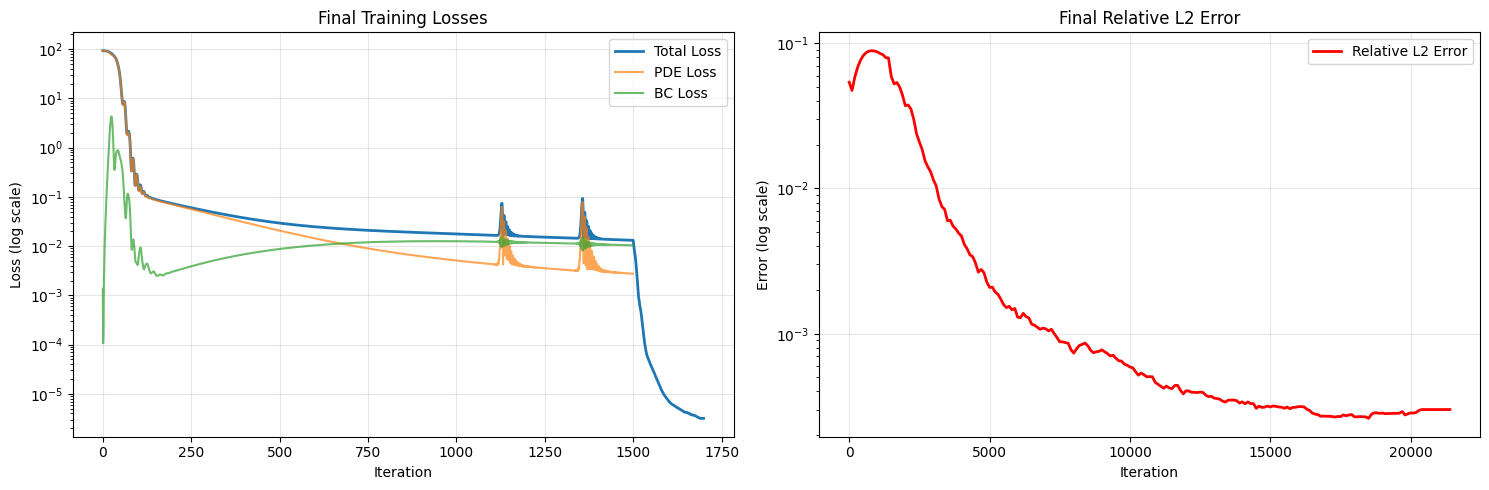


Best solution:


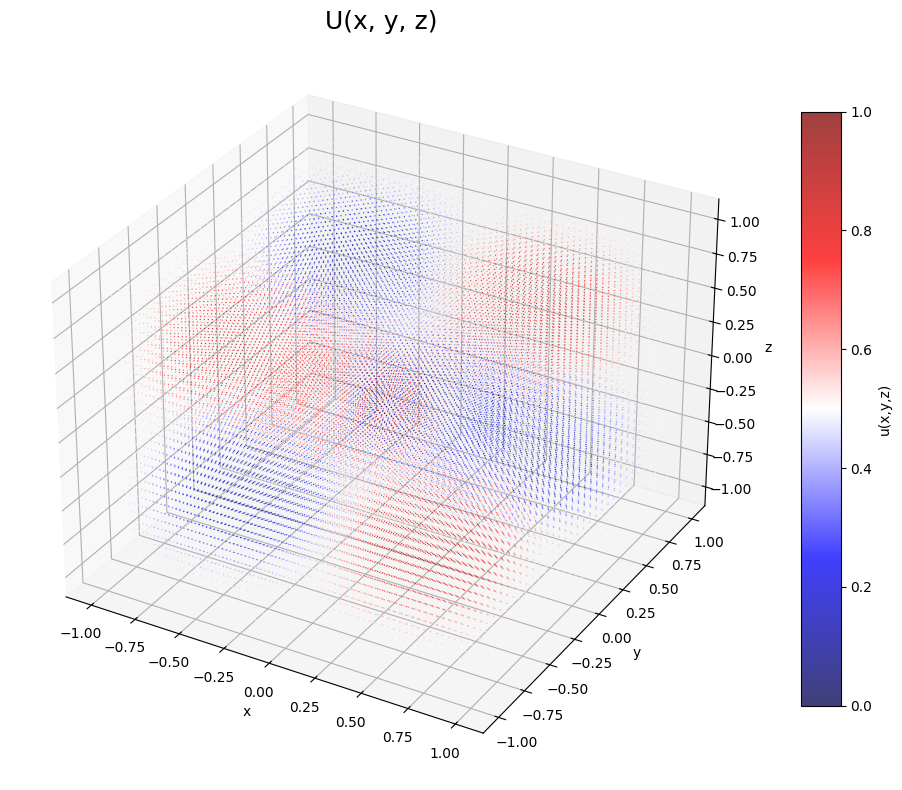

In [ ]:
EPOCHS_ADAM = 1500
EPOCHS_LBFGS = 200
LOG_ITER = 100
RESAMPLE_ITER = 100
N_PER_AXIS = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaseSPINN(
    rank=64,
    hidden_dim=96,
    n_hidden_layers=4,
    n_points=32,
    k=1.0,
    a1=1,
    a2=1,
    a3=1,
    device=device,
).to(device)
model.apply(init_modified_mlp_)
N_test = 32
x = torch.linspace(-1, 1, N_test, device=device)
y = torch.linspace(-1, 1, N_test, device=device)
z = torch.linspace(-1, 1, N_test, device=device)
xx_test, yy_test, zz_test = torch.meshgrid(x, y, z, indexing="ij")
u_test = model.reference_solution(xx_test, yy_test, zz_test)

adam_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    adam_optimizer,
    mode="min",
    factor=0.5,
    patience=200,
)
history, best_error, best_u = train_spinn_adam_lbfgs(
    model=model,
    adam_optimizer=adam_optimizer,
    scheduler=scheduler,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs_adam=EPOCHS_ADAM,
    epochs_lbfgs=EPOCHS_LBFGS,
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    N_per_axis=N_PER_AXIS,
    domain_size=1.0,
    device=device,
    pde_weight=1.0,
    bc_weight=1.0,
)

После обучения посчитайте итоговые метрики на тестовой сетке.

> Подбирайте качество за счёт корректной архитектуры, выбора гиперпараметров и настройки обучения, не используя прямую подгонку под тестовую сетку. За такое бан.

In [ ]:
model.eval()
with torch.no_grad():
    u_pred_final = model(xx_test[:, 0, 0], yy_test[0, :, 0], zz_test[0, 0, :])

mse = ((u_test.cpu().numpy() - u_pred_final.cpu().numpy()) ** 2).mean()
rel_l2 = relative_l2(u_pred_final, u_test).item()

print(f"MSE: {mse:.2e}")
print(f"Relative L2: {rel_l2:.2e}")

MSE: 1.63e-08
Relative L2: 3.79e-04


In [ ]:
score_1_2 = 0.0
if mse <= 5e-3:
    score_1_2 = 0.5 * 1.5
if mse <= 5e-4:
    score_1_2 = 0.6 * 1.5
if mse <= 1e-5:
    score_1_2 = 0.7 * 1.5
if mse <= 1e-7:
    score_1_2 = 0.9 * 1.5
if mse <= 5e-8:
    score_1_2 = 1.0 * 1.5

print(f"Баллы за пункт 1.2: {score_1_2:.2f} / 1.5")

Баллы за пункт 1.2: 1.50 / 1.5


Оценка за пункт 1.2 зависит от наилучшего достигнутого порога по `mse`: каждому порогу соответствует своя доля из **1,5 балла** за качество. Итоговый балл определяется по самому строгому из выполненных условий.

> **Примечание.** Итоговые пороги качества для этой части будут проверяться по метрикам на тестовой сетке. Не забывайте сохранить веса лучшей модели: они понадобятся при сдаче домашнего задания.

In [ ]:
torch.save(model.state_dict(), "best_spinn_model.pth")

### Задание 1.3. Краткий анализ (0,5 балла)

После обучения кратко опишите, как вы подбирали конфигурацию модели и что наблюдали в экспериментах.

Можно обсудить:

1. С каких параметров вы начали и к какой конфигурации пришли в итоге.
2. Как изменение `rank` влияло на качество и время обучения.
3. Что сильнее влияло на результат: архитектура body-сетей, плотность коллокационной решётки или баланс между `PDE loss` и `BC loss`.
4. Были ли признаки того, что модель реализована некорректно или обучается неустойчиво, и как вы это диагностировали.

`Анализ: # your text here (ಠ.ಠ)`
1. Параметры подбирались постепенно, от базовой конфигурации к более устойчивой по ошибке и времени обучения.

2. Увеличение `rank` обычно улучшало качество, но заметно замедляло обучение.

3. На результат сильнее всего влияли плотность сетки и баланс между `PDE loss` и `BC loss`.

4. Неустойчивость проявлялась в слабом улучшении ошибки при уменьшении loss и в чувствительности к гиперпараметрам. Это диагностировалось по динамике метрик в ходе обучения.

## Часть 2. Классификация звуков UrbanSound8K с помощью CNN (6 баллов)


### Разбалловка

Во второй части нужно пройти весь стандартный пайплайн аудиоклассификации: подготовить данные, реализовать модель, обучить её и провести итоговую оценку.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 2.1 Подготовка данных и Dataset | **1,0** | Корректный fold-aware pipeline, реализация `UrbanSoundDataset`, аккуратная работа с метками |
| 2.2 Архитектура CNN | **1,0** | Рабочая сверточная модель для классификации мел-спектрограмм |
| 2.3 Обучение и валидация | **1,0** | Реализация train/validate, early stopping, осмысленная настройка обучения |
| 2.4 Качество модели | **2,5** | Итоговое качество по accuracy |
| 2.5 Краткий анализ | **0,5** | Наблюдения по архитектуре, аугментациям, ошибкам модели и качеству |

> В этой части важно не только получить хороший score, но и корректно организовать эксперимент. Использование правильного протокола разбиения данных здесь является частью задания, а не технической деталью.

### Введение в обработку аудио

#### Почему не всегда удобно работать с сырым аудиосигналом?

Аудиосигнал - это последовательность амплитудных отсчётов во времени. Например, 4-секундный фрагмент при частоте дискретизации 22 050 Гц содержит около 88 тысяч значений. Теоретически такие данные можно подавать напрямую в нейросеть, но на практике это не самый удобный вариант:

1. **Высокая размерность.** Даже короткий сигнал содержит много отсчётов.
2. **Сложная временная структура.** В сигнале одновременно важны и короткие локальные паттерны, и более длинные зависимости.
3. **Частотная информация скрыта неявно.** По самому временному ряду не так удобно понять, какие частоты присутствуют в сигнале.

**Спектрограммы**

Это представление сигнала в плоскости "время–частота". Она строится с помощью кратковременного преобразования Фурье (STFT): сигнал разбивается на короткие окна, для каждого окна вычисляется частотный спектр, после чего эти спектры собираются по времени.

В результате получается 2D-представление, где:
- по оси X идёт время;
- по оси Y - частота;
- цвет отражает энергию сигнала на данной частоте в данный момент.

**Мел-спектрограмма**

Обычная спектрограмма полезна, но не полностью соответствует тому, как человек воспринимает звук. Поэтому в задачах аудиоклассификации часто используют мел-спектрограммы.

Идея здесь в том, что:
- частоты переводятся в мел-шкалу, которая лучше соответствует человеческому слуху;
- амплитуды обычно переводятся в децибельную шкалу, то есть в логарифмический масштаб.

Мел-спектрограммы удобны по нескольким причинам:
1. уменьшают размерность;
2. сохраняют наиболее важную перцептивную информацию;
3. дают 2D-представление, с которым удобно работать при помощи CNN.

Именно поэтому в этой части домашнего задания мы будем классифицировать не сырые аудиосигналы, а именно - мел-спектрограммы.

![Пример мел-спектрограммы](https://manual.audacityteam.org/m/images/e/ed/mel_log_linear_spectrogram_annotated.png)

*Пример мел-спектрограммы: ось X - время, ось Y - частота по мел-шкале, цвет отражает амплитуду (от тёмных = низкая энергия до ярких = высокая энергия)*

Источники - [курс DLA](https://github.com/markovka17/dla), [audacity](https://manual.audacityteam.org/man/spectrogram_view.html)

### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Скачиваем UrbanSound8K отсюда https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Важное замечание про протокол разбиения**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`;
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  
При этом `shuffle=True` внутри `train_loader` использовать можно.

In [ ]:
!pip install soundata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.0/162.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.1 MB/s eta 0:00:00


In [ ]:
import soundata
dataset = soundata.initialize('urbansound8k')

In [ ]:
import soundata
import os
import pandas as pd

dataset = soundata.initialize("urbansound8k")
dataset.download()

DATASET_PATH = dataset.data_home
METADATA_PATH = os.path.join(DATASET_PATH, "metadata", "UrbanSound8K.csv")

print("DATASET_PATH:", DATASET_PATH)
print("METADATA_PATH:", METADATA_PATH)
print("CSV exists:", os.path.exists(METADATA_PATH))

metadata = pd.read_csv(METADATA_PATH)
print(len(metadata))
print(metadata["class"].value_counts().sort_index())

5.61GB [01:46, 56.4MB/s]                            
1.15MB [00:00, 4.10MB/s]                           


DATASET_PATH: /root/sound_datasets/urbansound8k
METADATA_PATH: /root/sound_datasets/urbansound8k/metadata/UrbanSound8K.csv
CSV exists: True
8732
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

Sample: 117181-8-0-8.wav
Class: siren
Fold: 8



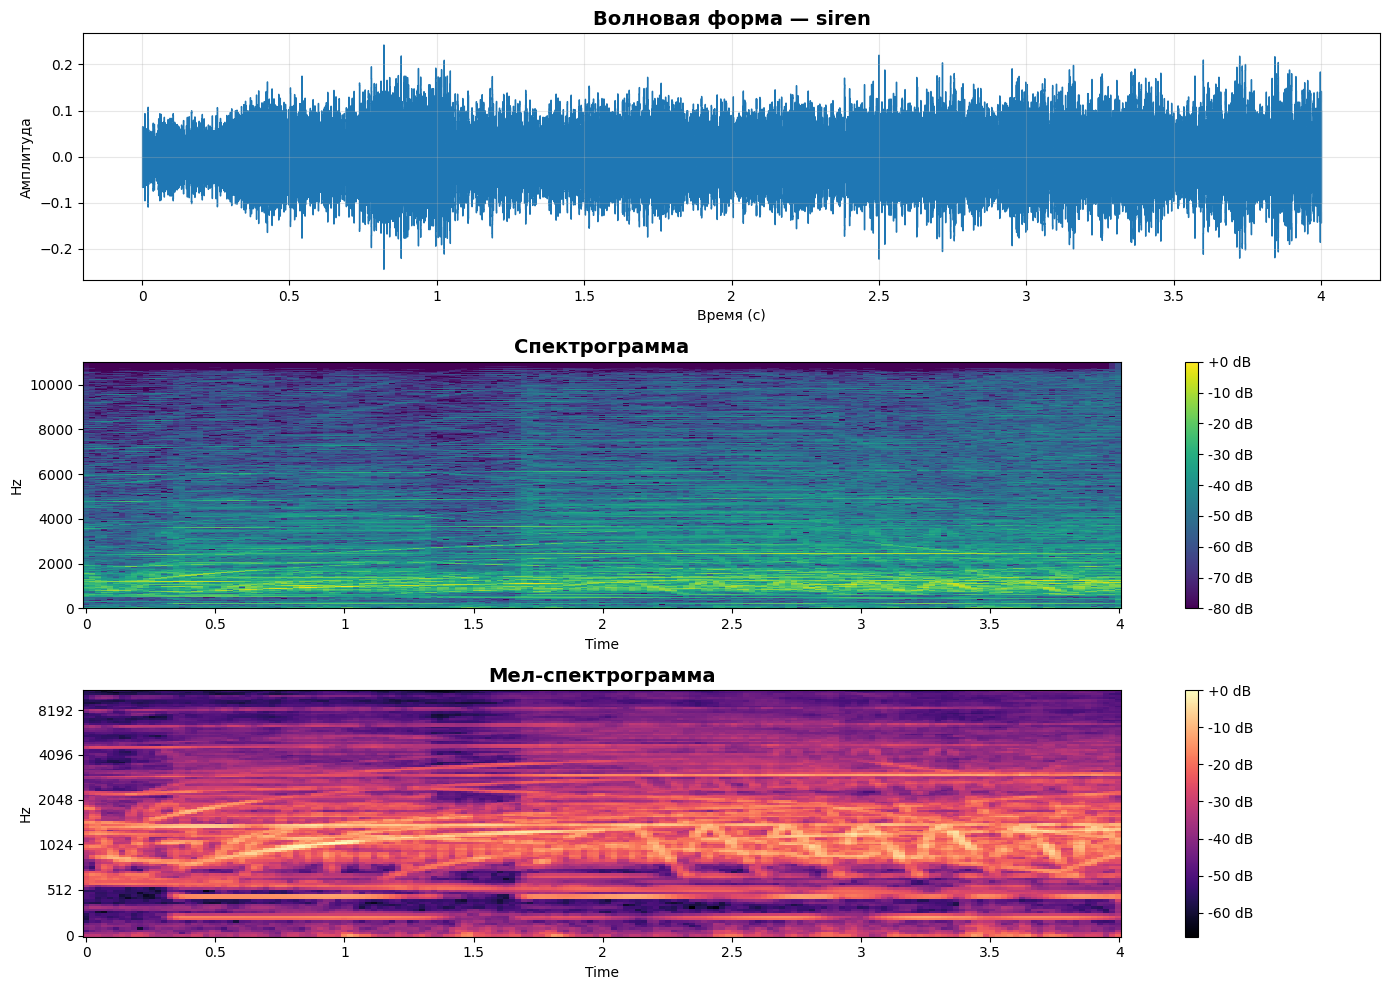

In [ ]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis"
    )
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma"
    )
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr


random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, "audio", f"fold{sample.fold}", sample.slice_file_name)
print(f"Sample: {sample.slice_file_name}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample.fold}\n")

y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
Audio(y, rate=sr)

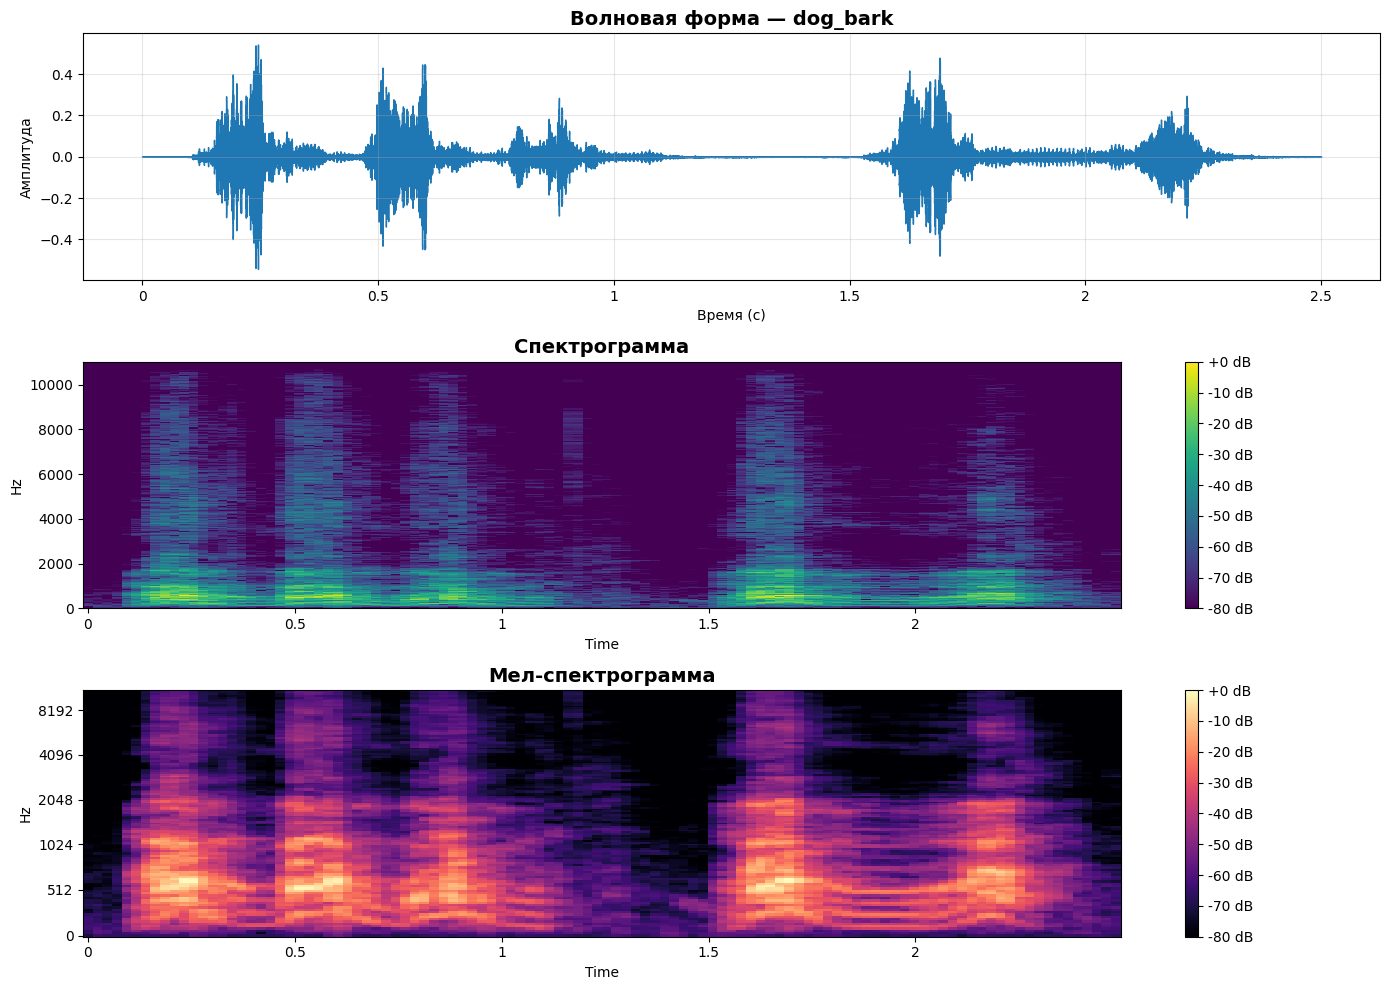

In [ ]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

### Задание 2.1. Подготовьте датасет к обучению модели (1 балл)

В этой части нужно реализовать `UrbanSoundDataset`.

Несколько важных условий:

- используйте официальные fold'ы;
- не делайте `fit` для `LabelEncoder` отдельно на каждом split;
- не извлекайте мел-спектрограммы заново при каждом обращении к `__getitem__`, если этого можно избежать.

**Последний пункт особенно важен.** Извлечение спектрограмм через `librosa` - CPU-bound операция, и если делать её на лету для каждого батча, обучение быстро начинает тормозить не из-за модели, а из-за препроцессинга. Поэтому в этой задаче рекомендуется один раз подготовить спектрограммы и либо держать их в памяти, либо кэшировать на диск.

Идея простая: `__getitem__` должен быть как можно легче. В идеале там уже не должно происходить ничего дорогого, кроме извлечения готового тензора и, при необходимости, несложной аугментации.

In [ ]:
# Единый LabelEncoder

ALL_CLASSES = sorted(metadata["class"].unique())
global_label_encoder = LabelEncoder()
global_label_encoder.fit(ALL_CLASSES)

print(f"Классы ({len(global_label_encoder.classes_)}):")
print(list(global_label_encoder.classes_))

Классы (10):
[np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


In [ ]:
import os
import uuid
import numpy as np
import torch
from torch.utils.data import Dataset
import librosa


class UrbanSoundDataset(Dataset):
    def __init__(
        self,
        metadata,
        dataset_path,
        label_encoder,
        target_length=4,
        sr=22050,
        n_mels=128,
        augment=False,
        cache_dir=None,
    ):
        self.metadata = metadata.reset_index(drop=True).copy()
        self.dataset_path = dataset_path
        self.label_encoder = label_encoder
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment
        self.target_samples = int(target_length * sr)

        if cache_dir is None:
            cache_dir = os.path.join(dataset_path, "mel_cache")
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

        self.labels = self.label_encoder.transform(self.metadata["class"])
        self.num_classes = len(self.label_encoder.classes_)

        self.expected_frames = 1 + self.target_samples // 512
        self.expected_shape = (self.n_mels, self.expected_frames)

    def __len__(self):
        return len(self.metadata)

    def load_audio(self, file_path):
        y, _ = librosa.load(file_path, sr=self.sr, mono=True)

        if len(y) > self.target_samples:
            y = y[:self.target_samples]
        elif len(y) < self.target_samples:
            y = np.pad(y, (0, self.target_samples - len(y)), mode="constant")

        return y.astype(np.float32)

    def extract_mel_spectrogram(self, y):
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=2048,
            hop_length=512,
            fmax=8000
        )
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)

        mean = mel_db.mean()
        std = mel_db.std() + 1e-6
        mel_db = (mel_db - mean) / std

        return mel_db.astype(np.float32)

    def augment_audio(self, y):
        if np.random.rand() < 0.5:
            shift = np.random.randint(-self.sr // 2, self.sr // 2)
            y = np.roll(y, shift)

        if np.random.rand() < 0.3:
            noise = np.random.randn(len(y)).astype(np.float32) * 0.005
            y = y + noise

        return np.clip(y, -1.0, 1.0).astype(np.float32)

    def spec_augment(self, mel_db, max_time_masks=2, max_freq_masks=2, max_time_width=20, max_freq_width=10):
        mel = mel_db.copy()
        num_mels, num_frames = mel.shape

        for _ in range(max_freq_masks):
            f = np.random.randint(0, max_freq_width + 1)
            if f == 0:
                continue
            f0 = np.random.randint(0, max(1, num_mels - f))
            mel[f0:f0+f, :] = 0

        for _ in range(max_time_masks):
            t = np.random.randint(0, max_time_width + 1)
            if t == 0:
                continue
            t0 = np.random.randint(0, max(1, num_frames - t))
            mel[:, t0:t0+t] = 0

        return mel.astype(np.float32)

    def _get_audio_path(self, row):
        return os.path.join(
            self.dataset_path,
            "audio",
            f"fold{row['fold']}",
            row["slice_file_name"]
        )

    def _get_cache_path(self, row):
        stem = os.path.splitext(row["slice_file_name"])[0]
        return os.path.join(
            self.cache_dir,
            f"{stem}_sr{self.sr}_mel{self.n_mels}_len{self.target_length}.npy"
        )

    def _is_valid_mel(self, mel_db):
        return (
            isinstance(mel_db, np.ndarray)
            and mel_db.size > 0
            and mel_db.shape == self.expected_shape
            and np.isfinite(mel_db).all()
        )

    def _atomic_save(self, array, cache_path):
        tmp_path = f"{cache_path}.tmp.{os.getpid()}.{uuid.uuid4().hex}.npy"
        np.save(tmp_path, array)
        os.replace(tmp_path, cache_path)

    def _build_and_cache_mel(self, file_path, cache_path):
        y = self.load_audio(file_path)
        mel_db = self.extract_mel_spectrogram(y)
        self._atomic_save(mel_db, cache_path)
        return mel_db

    def _load_or_create_cached_mel(self, file_path, cache_path):
        if os.path.exists(cache_path):
            try:
                mel_db = np.load(cache_path)
                if self._is_valid_mel(mel_db):
                    return mel_db
                raise ValueError(f"bad cache shape={getattr(mel_db, 'shape', None)}")
            except Exception as e:
                print(f"[Cache rebuild] {os.path.basename(cache_path)} -> {e}")
                try:
                    os.remove(cache_path)
                except OSError:
                    pass

        return self._build_and_cache_mel(file_path, cache_path)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        file_path = self._get_audio_path(row)

        if self.augment:
            y = self.load_audio(file_path)
            y = self.augment_audio(y)
            mel_db = self.extract_mel_spectrogram(y)
            mel_db = self.spec_augment(mel_db)
        else:
            cache_path = self._get_cache_path(row)
            mel_db = self._load_or_create_cached_mel(file_path, cache_path)

        mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)

        return mel_tensor, label_tensor

In [ ]:
def get_fold_split(metadata, test_fold, val_fold=None):
    """
    Разбиение по official folds.

    Если val_fold задан:
        train = все fold'ы, кроме test_fold и val_fold
        val   = val_fold
        test  = test_fold

    Если val_fold не задан:
        train = все fold'ы, кроме test_fold
        test  = test_fold
    """
    test_df = metadata[metadata["fold"] == test_fold]

    if val_fold is not None:
        assert val_fold != test_fold
        val_df = metadata[metadata["fold"] == val_fold]
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]
    else:
        val_df = None
        train_folds = [f for f in range(1, 11) if f != test_fold]

    train_df = metadata[metadata["fold"].isin(train_folds)]

    print(
        f"test={test_fold}"
        + (f", val={val_fold}" if val_fold is not None else "")
        + f" | Train: {len(train_df)}, Val: {len(val_df) if val_df is not None else 0}, Test: {len(test_df)}"
    )
    return train_df, val_df, test_df

#### Dev-split для быстрых экспериментов

Для подбора архитектуры и отладки удобно сначала работать на одном фиксированном разбиении:
- `train = folds 1–8`
- `val = fold 9`
- `test = fold 10`

Финальную 10-fold оценку лучше запускать уже после того, как основная конфигурация выбрана.

In [ ]:
train_df, val_df, test_df = get_fold_split(metadata, test_fold=10, val_fold=9)

BATCH_SIZE = 64

train_dataset = UrbanSoundDataset(
    train_df,
    DATASET_PATH,
    global_label_encoder,
    augment=True,
)

val_dataset = UrbanSoundDataset(
    val_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

test_dataset = UrbanSoundDataset(
    test_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"First labels: {sample_labels[:5]}")

test=10, val=9 | Train: 7079, Val: 816, Test: 837


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

Batch shape: torch.Size([64, 1, 128, 173])
Labels shape: torch.Size([64])
First labels: tensor([7, 8, 7, 9, 3])


### Задание 2.2. Реализуйте вашу архитектуру (1 балл)

В этой задаче разрешены только **свёрточные архитектуры**.

Нельзя использовать:
- RNN;
- LSTM / GRU;
- Transformer.

Можно использовать: обычные CNN-блоки, batch normalization, dropout,pooling, при желании - несложные attention-модули поверх CNN, если основа модели всё равно остаётся сверточной.

На вход модель получает мел-спектрограмму формы `(B, 1, n_mels, time)`, а на выходе должна возвращать логиты по 10 классам.

In [ ]:
class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5, channels=[1, 32, 64, 128, 256], fc_dim=128):
        # TODO: Реализуйте инициализацию слоев вашей архитектуры
        super(UrbanSoundCNN, self).__init__()

        self.num_classes = num_classes
        self.dropout = dropout
        self.channels = channels
        self.fc_dim = fc_dim

        layers = []
        for i in range(len(channels) - 1):
            in_ch = channels[i]
            out_ch = channels[i + 1]

            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            layers.append(nn.Dropout2d(0.2))

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes)
        )

    def forward(self, x):
        # TODO: Реализуйте forward вашей архитектуры
        x = self.features(x)
        x = self.classifier(x)
        return x

### Задание 2.3. Реализуйте обучение и валидацию модели (1 балл)

Теперь нужно написать код обучения модели на dev-split.

Ожидается, что у вас будут:
- функция `train_epoch`;
- функция `validate`;
- цикл обучения с early stopping;
- сохранение лучшей модели по качеству на валидации.

Здесь нет единственно правильной реализации, но ваш код должен быть аккуратным, воспроизводимым и согласованным с поставленной задачей.

In [ ]:
# TODO: Реализуйте функцию train_epoch(model, loader, criterion, optimizer, device)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# TODO: Реализуйте функцию validate(model, loader, criterion, device)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
model = UrbanSoundCNN(num_classes=train_dataset.num_classes).to(device)

# Считаем параметры
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Total parameters: 422,986
Trainable parameters: 422,986

Model architecture:
UrbanSoundCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

NUM_EPOCHS = 50
PATIENCE = 15

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if new_lr != old_lr:
        print(f"LR reduced: {old_lr:.6f} -> {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print(f"\n{'='*60}")
print(f"Training complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}")

Starting training for 50 epochs...


Epoch 1/50
------------------------------------------------------------
Train Loss: 1.9433 | Train Acc: 28.00%
Val Loss: 1.7422 | Val Acc: 38.60%
✓ New best model saved! (Val Acc: 38.60%)

Epoch 2/50
------------------------------------------------------------
Train Loss: 1.6247 | Train Acc: 39.85%
Val Loss: 1.6283 | Val Acc: 45.59%
✓ New best model saved! (Val Acc: 45.59%)

Epoch 3/50
------------------------------------------------------------
Train Loss: 1.4696 | Train Acc: 45.42%
Val Loss: 1.5269 | Val Acc: 47.55%
✓ New best model saved! (Val Acc: 47.55%)

Epoch 4/50
------------------------------------------------------------
Train Loss: 1.3725 | Train Acc: 49.00%
Val Loss: 1.4982 | Val Acc: 44.98%

Epoch 5/50
------------------------------------------------------------
Train Loss: 1.3193 | Train Acc: 52.15%
Val Loss: 1.3828 | Val Acc: 55.51%
✓ New best model saved! (Val Acc: 55.51%)

Epoch 6/50
-------------------------------------------------

После обучения оцените модель на test-части dev-split. Затем постройте confusion matrix и посмотрите, какие классы модель путает чаще всего.

In [ ]:
# model.load_state_dict(torch.load("best_cnn_model.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy on dev-split: {test_acc * 100:.2f}%")

Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Test accuracy on dev-split: 78.14%


In [ ]:
import seaborn as sns

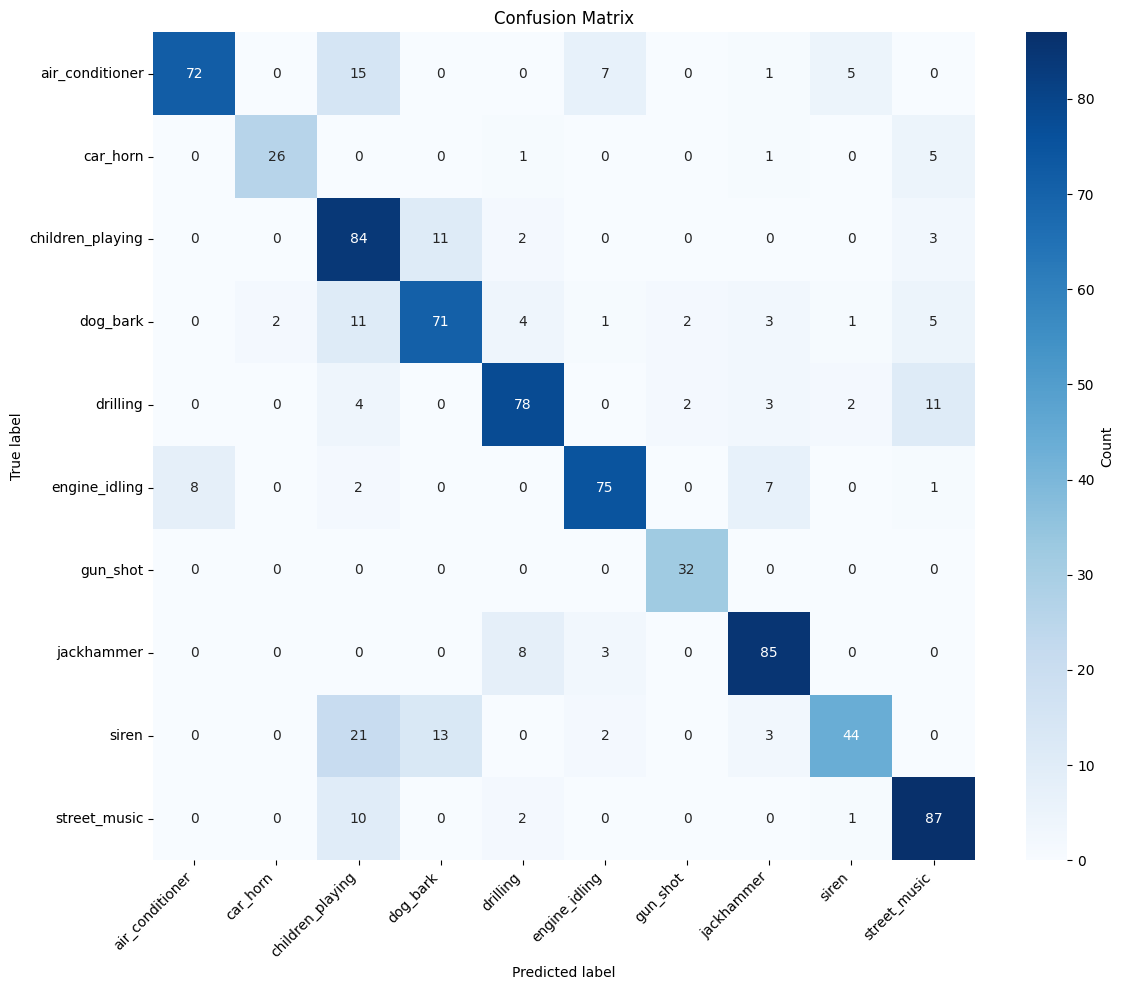

                  precision    recall  f1-score   support

 air_conditioner     0.9000    0.7200    0.8000       100
        car_horn     0.9286    0.7879    0.8525        33
children_playing     0.5714    0.8400    0.6802       100
        dog_bark     0.7474    0.7100    0.7282       100
        drilling     0.8211    0.7800    0.8000       100
   engine_idling     0.8523    0.8065    0.8287        93
        gun_shot     0.8889    1.0000    0.9412        32
      jackhammer     0.8252    0.8854    0.8543        96
           siren     0.8302    0.5301    0.6471        83
    street_music     0.7768    0.8700    0.8208       100

        accuracy                         0.7814       837
       macro avg     0.8142    0.7930    0.7953       837
    weighted avg     0.7983    0.7814    0.7813       837



In [ ]:
cm = confusion_matrix(all_labels, all_preds)
class_names = global_label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

### Задание 2.4. Финальная 10-fold оценка (2,5 балла)

После того как вы подобрали рабочую конфигурацию на dev-split, проведите один финальный прогон 10-fold cross-validation.

Для каждого `test_fold`:
- `val_fold` берётся как следующий fold по кругу;
- все остальные fold'ы идут в train.

Итоговое качество считается по средней accuracy по всем 10 fold'ам.

In [ ]:
def evaluate_10fold(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    dataset_path,
    label_encoder,
    device="cuda",
    verbose=True,
):
    """
    10-fold CV по folds UrbanSound8K
    """
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = UrbanSoundDataset(train_df, dataset_path, label_encoder, augment=True)
        val_ds = UrbanSoundDataset(val_df, dataset_path, label_encoder, augment=False)
        test_ds = UrbanSoundDataset(test_df, dataset_path, label_encoder, augment=False)

        loader_kwargs = dict(num_workers=0, pin_memory=False)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, **loader_kwargs)
        test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, **loader_kwargs)
        model = model_class(**model_kwargs).to(device)
        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

In [ ]:
import time
import numpy as np

def my_train_fn(model, train_loader, val_loader, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=1
    )

    NUM_EPOCHS = 15
    PATIENCE = 2

    best_val_acc = 0.0
    best_state = None
    patience_counter = 0
    epoch_times = []

    fold_start = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()
        print(f"  Starting epoch {epoch+1}/{NUM_EPOCHS}...")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        avg_epoch_time = np.mean(epoch_times)
        remaining_epochs = NUM_EPOCHS - (epoch + 1)
        est_remaining = avg_epoch_time * remaining_epochs

        print(
            f"  Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}% | "
            f"time={epoch_time/60:.1f} min | "
            f"ETA fold={est_remaining/60:.1f} min"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    total_fold_time = time.time() - fold_start
    print(f"  Fold training time: {total_fold_time/60:.1f} min")

    return model

In [ ]:
#предтрен, чтобы заранее получить веса и обучать модель не как слепой котёнок
model_config = {
    "num_classes": 10,
    "channels": [1, 32, 64, 128, 256, 512],
    "fc_dim": 256,
}
pretrain_train_df, pretrain_val_df, _ = get_fold_split(metadata, test_fold=10, val_fold=9)

pretrain_train_ds = UrbanSoundDataset(pretrain_train_df, DATASET_PATH, global_label_encoder, augment=True)
pretrain_val_ds   = UrbanSoundDataset(pretrain_val_df,   DATASET_PATH, global_label_encoder, augment=False)

loader_kwargs = dict(num_workers=4, pin_memory=True)
pretrain_train_loader = DataLoader(pretrain_train_ds, batch_size=64, shuffle=True,  **loader_kwargs)
pretrain_val_loader   = DataLoader(pretrain_val_ds,   batch_size=64, shuffle=False, **loader_kwargs)

pretrain_model = UrbanSoundCNN(**model_config).to(device)
pretrain_model = my_train_fn(pretrain_model, pretrain_train_loader, pretrain_val_loader, device)

torch.save(pretrain_model.state_dict(), "urbansound_pretrained.pth")
print("Saved pretrained weights.")

test=10, val=9 | Train: 7079, Val: 816, Test: 837
  Starting epoch 1/15...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch 1/15 | train_loss=1.9526 train_acc=27.65% | val_loss=1.6865 val_acc=42.28% | time=4.4 min | ETA fold=61.4 min
  Starting epoch 2/15...
  Epoch 2/15 | train_loss=1.5494 train_acc=43.23% | val_loss=1.4543 val_acc=56.62% | time=4.0 min | ETA fold=54.5 min
  Starting epoch 3/15...
  Epoch 3/15 | train_loss=1.3810 train_acc=50.05% | val_loss=1.2218 val_acc=59.56% | time=3.7 min | ETA fold=48.5 min
  Starting epoch 4/15...
  Epoch 4/15 | train_loss=1.2605 train_acc=53.68% | val_loss=1.2541 val_acc=63.97% | time=3.7 min | ETA fold=43.6 min
  Starting epoch 5/15...
  Epoch 5/15 | train_loss=1.1988 train_acc=56.48% | val_loss=1.1641 val_acc=65.20% | time=3.7 min | ETA fold=39.1 min
  Starting epoch 6/15...
  Epoch 6/15 | train_loss=1.1243 train_acc=60.31% | val_loss=1.0901 val_acc=63.48% | time=3.7 min | ETA fold=34.9 min
  Starting epoch 7/15...
  Epoch 7/15 | train_loss=1.0640 train_acc=61.87% | val_loss=1.0453 val_acc=69.12% | time=3.6 min | ETA fold=30.7 min
  Starting epoch 8/15...

In [ ]:
model_config = {
    "num_classes": 10,
    "channels": [1, 32, 64, 128, 256, 512],
    "fc_dim": 256,
}
def evaluate_10fold_pretrained(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    dataset_path,
    label_encoder,
    pretrained_path,
    device="cpu",
    verbose=True,
):
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = UrbanSoundDataset(train_df, dataset_path, label_encoder, augment=True)
        val_ds = UrbanSoundDataset(val_df, dataset_path, label_encoder, augment=False)
        test_ds = UrbanSoundDataset(test_df, dataset_path, label_encoder, augment=False)

        loader_kwargs = dict(num_workers=2, pin_memory=True)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kwargs)
        test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, **loader_kwargs)

        model = model_class(**model_kwargs).to(device)

        state_dict = torch.load(pretrained_path, map_location=device)
        model.load_state_dict(state_dict, strict=False)

        if verbose:
            print(f"Loaded pretrained weights from: {pretrained_path}")

        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

In [ ]:
accuracies = evaluate_10fold_pretrained(
    model_class=UrbanSoundCNN,
    model_kwargs=model_config,
    train_fn=my_train_fn,
    metadata=metadata,
    dataset_path=DATASET_PATH,
    label_encoder=global_label_encoder,
    pretrained_path="urbansound_pretrained.pth",
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])
Loaded pretrained weights from: urbansound_pretrained.pth
  Starting epoch 1/15...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Epoch 1/15 | train_loss=0.8155 train_acc=73.00% | val_loss=0.6442 val_acc=75.90% | time=18.9 min | ETA fold=264.7 min
  Starting epoch 2/15...
  Epoch 2/15 | train_loss=0.7901 train_acc=73.59% | val_loss=0.5404 val_acc=79.05% | time=18.2 min | ETA fold=241.3 min
  Starting epoch 3/15...
  Epoch 3/15 | train_loss=0.7416 train_acc=75.25% | val_loss=0.5958 val_acc=77.36% | time=17.9 min | ETA fold=220.2 min
  Starting epoch 4/15...
  Epoch 4/15 | train_loss=0.7269 train_acc=76.03% | val_loss=0.5318 val_acc=78.94% | time=18.0 min | ETA fold=201.0 min
  Early stopping at epoch 4
  Fold training time: 73.1 min
Fold 1 accuracy: 84.19%

Fold 2/10 (val=3, train=[1, 4, 5, 6, 7, 8, 9, 10])
Loaded pretrained weights from: urbansound_pretrained.pth
  Starting epoch 1/15...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


по причине того что в коллабе фолды идут пипец как долго и упираются в лимит гпу, всё задание 2.4 будет сдано в другом ноутбуке на кагле(у меня вылез лимит импорта в 1мб поэтому пришлось делать два разных ноутбука), который тоже будет прикреплён, тут дальше ток выводы читать нужно.

In [ ]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

for i, acc in enumerate(accuracies, 1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\n10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

Баллы за пункт 2.4 начисляются в зависимости от лучшего выполненного порога по средней accuracy в 10-fold CV: чем выше итоговое качество, тем больше доля из 2,5 балла за эту часть.

In [ ]:
score_2_4 = 0.0

if mean_acc >= 0.64:
    score_2_4 = 0.5 * 2.5
if mean_acc >= 0.69:
    score_2_4 = 0.6 * 2.5
if mean_acc >= 0.74:
    score_2_4 = 0.7 * 2.5
if mean_acc >= 0.79:
    score_2_4 = 0.8 * 2.5
if mean_acc >= 0.84:
    score_2_4 = 0.9 * 2.5
if mean_acc >= 0.88:
    score_2_4 = 1.0 * 2.5

print(f"Mean CV accuracy: {mean_acc:.4f}")
print(f"Баллы за пункт 2.4: {score_2_4:.2f} / 2.5")

### Задание 2.5. Краткий анализ (0,5 балла)

В конце прокомментируйте свою работу:

1. Какую архитектуру вы выбрали и почему.
2. Какие аугментации оказались полезными, а какие нет.
3. Что сильнее влияло на качество: сама CNN, preprocessing или параметры обучения.
4. Какие классы модель путала чаще всего и почему это выглядит правдоподобно.
5. Насколько различались результаты между fold'ами.


`Анализ: # your text here (ಠ.ಠ)`

1. выбрали обычную CNN на лог-мел-спектрограммах, потому что для аудио это простой и понятный baseline: спектрограмму можно воспринимать почти как картинку, а CNN хорошо ловит локальные паттерны
2. Из аугментаций полезными оказались простые вещи: случайный сдвиг по времени и добавление небольшого шума. Они делали модель более устойчивой, а слишком сложные или агрессивные на коротких звуках они уже мешали.
3. Мне кажется, что на качество сильнее всего повлияли preprocessing и параметры обучения, а не только сама CNN. Нормализация mel-спектрограмм, фиксированная длина аудио, scheduler и early stopping дали заметный эффект на стабильность обучения.
4. По confusion matrix видно, что модель чаще путала классы, которые похожи по звучанию, например siren, dog_bark и children_playing. Это выглядит правдоподобно, потому что у них может быть похожая шумовая или резкая временная структура.
5. Результаты по fold'ам отличались не сильно, средняя точность составила 81.44%,  разброс был небольшим. Лучше всего модель сработала на Fold 1, хуже всего  на Fold 9 и 10, но в целом качество осталось достаточно стабильным.